# 1. Load Libraries

In [53]:
pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 4.3 MB/s eta 0:00:00


In [54]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.datasets import fashion_mnist
import tensorflow as tf
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

#2. Load Dataset
Note: dataset is in the form of numpy array

In [15]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()
print(type(X_train))

<class 'numpy.ndarray'>


# 3. Exploratory Data Analysis (EDA)


### 1. Shape of trainging and testing features and labels

In [33]:
print("Training Images Shape:", X_train.shape)
print("Training Labels Shape:", y_train.shape)
print("Testing Images Shape:", X_test.shape)
print("Testing Labels Shape:", y_test.shape)
print(X_train[0].shape)    # images are 28 * 28 pixels

Training Images Shape: (60000, 28, 28)
Training Labels Shape: (60000,)
Testing Images Shape: (10000, 28, 28)
Testing Labels Shape: (10000,)
(28, 28)


### 2. First 30 Labels

In [20]:
print(y_train[:30])


[9 0 0 3 0 2 7 2 5 5 0 9 5 5 7 9 1 0 6 4 3 1 4 8 4 3 0 2 4 4]


### 3. Display 2nd image

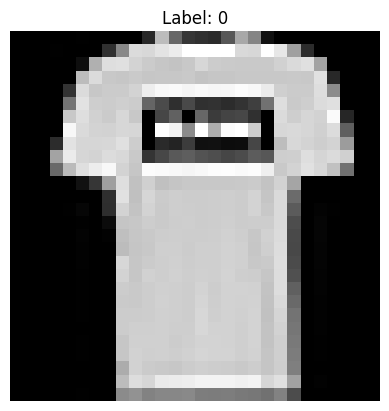

In [26]:
plt.imshow(X_train[1], cmap="gray")
plt.title(f"Label: {y_train[1]}")
plt.axis("off")
plt.show()

### 4. Display Images

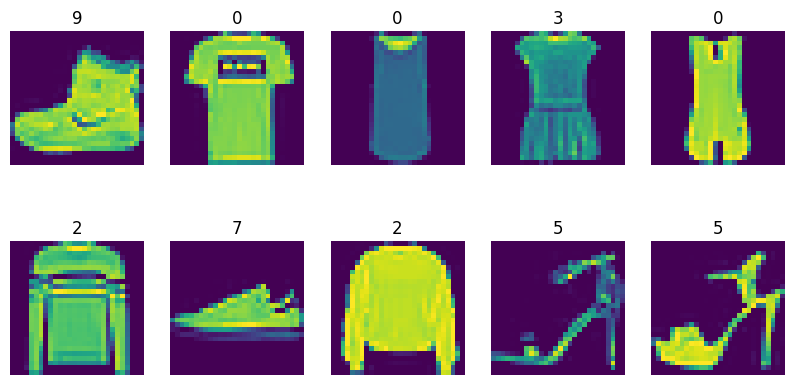

In [29]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], )
    plt.title(y_train[i])
    plt.axis("off")   # off labels of axis
plt.show()

### 5. Datatype

In [34]:
print(X_train.dtype)
print(y_train.dtype)

uint8
uint8


### 6. Pixel Range

In [35]:
print("Minimum Pixel:", X_train.min())
print("Maximum Pixel:", X_train.max())

Minimum Pixel: 0
Maximum Pixel: 255


### 7. Image count in each class

In [38]:
labels, counts = np.unique(y_train, return_counts=True)
for label, count in zip(labels, counts):
    print(f"Class {label}: {count} images")

Class 0: 6000 images
Class 1: 6000 images
Class 2: 6000 images
Class 3: 6000 images
Class 4: 6000 images
Class 5: 6000 images
Class 6: 6000 images
Class 7: 6000 images
Class 8: 6000 images
Class 9: 6000 images


### 8. Display pixel Value

In [39]:
print(X_train[0])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0
    0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62
   54   0   0   0   1   3   4   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134
  144 123  23   0   0   0   0  12  10   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 178
  107 156 161 109  64  23  77 130  72  15]
 [  0   0   0   0   0   0   0   0   0   0   0   1   0  69 207 223 218 216
  216 163 127 121 122 146 141  88 172  66]
 [  0   0   0   0   0   0   0   0   0   1   1   1   0 200 232 23

### 9. Image Dimensions

In [40]:
print("Height:", X_train.shape[1])
print("Width:", X_train.shape[2])

Height: 28
Width: 28


### 10. Training Testing Samples

In [41]:
print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 60000
Testing Samples: 10000


### 11. Check Missing Values

In [44]:
import numpy as np
print(np.isnan(X_train).sum())

0


# 4. Normalize the Images
Note: divide by 255 because it is max value of pixel in this dataset

In [48]:
# Normalize pixel values
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [49]:
print("After Normalization")
print("Minimum Pixel Value:", X_train.min())
print("Maximum Pixel Value:", X_train.max())
print("Data Type:", X_train.dtype)

After Normalization
Minimum Pixel Value: 0.0
Maximum Pixel Value: 1.0
Data Type: float32


# 5. Hyperparamter Tunning

Model Building Function

In [55]:
def build_model(hp):

    model = Sequential()

    model.add(Flatten(input_shape=(28, 28)))

    # First Hidden Layer
    model.add(
        Dense(
            units=hp.Int("units1", min_value=32, max_value=256, step=32),
            activation=hp.Choice("activation1", ["relu", "tanh"])
        )
    )

    # Second Hidden Layer
    model.add(
        Dense(
            units=hp.Int("units2", min_value=32, max_value=256, step=32),
            activation=hp.Choice("activation2", ["relu", "tanh"])
        )
    )

    # Output Layer
    model.add(Dense(10, activation="softmax"))

    # Learning Rate
    learning_rate = hp.Choice(
        "learning_rate",
        values=[0.01, 0.001, 0.0001]
    )

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=learning_rate
    )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

Create the Tuner

In [56]:
tuner = kt.RandomSearch(
    build_model,
    objective="val_accuracy",
    max_trials=10,
    executions_per_trial=1,
    directory="keras_tuner",
    project_name="fashion_mnist"
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [57]:
tuner.search(
    X_train,
    y_train,
    epochs=5,
    validation_split=0.2
)

Trial 10 Complete [00h 00m 35s]
val_accuracy: 0.8772500157356262

Best val_accuracy So Far: 0.8830833435058594
Total elapsed time: 00h 07m 07s


In [58]:
best_hp = tuner.get_best_hyperparameters(1)[0]

print("Best Parameters")
print("---------------------------")
print("Units Layer 1:", best_hp.get("units1"))
print("Activation 1 :", best_hp.get("activation1"))
print("Units Layer 2:", best_hp.get("units2"))
print("Activation 2 :", best_hp.get("activation2"))
print("Learning Rate:", best_hp.get("learning_rate"))

Best Parameters
---------------------------
Units Layer 1: 160
Activation 1 : relu
Units Layer 2: 128
Activation 2 : relu
Learning Rate: 0.001


# 6. Model Building

In [59]:
best_model = tuner.hypermodel.build(best_hp)

# 7. Model Training

In [60]:
history = best_model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8204 - loss: 0.5009 - val_accuracy: 0.8566 - val_loss: 0.3911
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8622 - loss: 0.3722 - val_accuracy: 0.8618 - val_loss: 0.3745
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8776 - loss: 0.3327 - val_accuracy: 0.8733 - val_loss: 0.3498
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8847 - loss: 0.3105 - val_accuracy: 0.8625 - val_loss: 0.3868
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.8909 - loss: 0.2921 - val_accuracy: 0.8824 - val_loss: 0.3308
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8981 - loss: 0.2747 - val_accuracy: 0.8836 - val_loss: 0.3294
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9016 - loss: 0.2608 - val_accuracy: 0.8757 - val_loss: 0.3456
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9057 - loss: 0.2518

# 8. Model Evaluation

In [62]:
test_loss, test_accuracy = best_model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8851 - loss: 0.3452
Test Loss: 0.3451758623123169
Test Accuracy: 0.8851000070571899


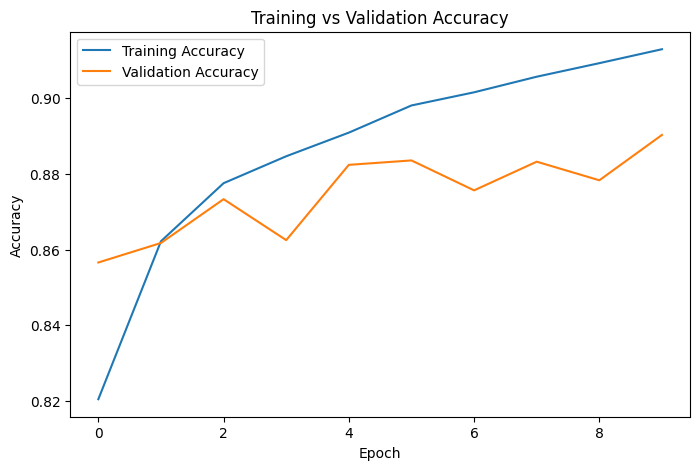

In [61]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [63]:
print("Training Accuracy:")
print(history.history["accuracy"])

print("\nValidation Accuracy:")
print(history.history["val_accuracy"])

Training Accuracy:
[0.8204166889190674, 0.8622083067893982, 0.8775625228881836, 0.8846874833106995, 0.8909375071525574, 0.8981249928474426, 0.901604175567627, 0.9057291746139526, 0.9093124866485596, 0.9129999876022339]

Validation Accuracy:
[0.8565833568572998, 0.8617500066757202, 0.8733333349227905, 0.862500011920929, 0.8824166655540466, 0.8835833072662354, 0.8756666779518127, 0.8832499980926514, 0.878333330154419, 0.890333354473114]


# 9. Predictions on Test Images

In [64]:

# Predict probabilities
predictions = best_model.predict(X_test)
# Convert probabilities to class labels
predicted_labels = np.argmax(predictions, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [70]:
print(predicted_labels)

[9 2 1 ... 8 1 5]


# 10. Display Predicted and Actual Labels

In [66]:
class_names = [
    "T-shirt/Top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

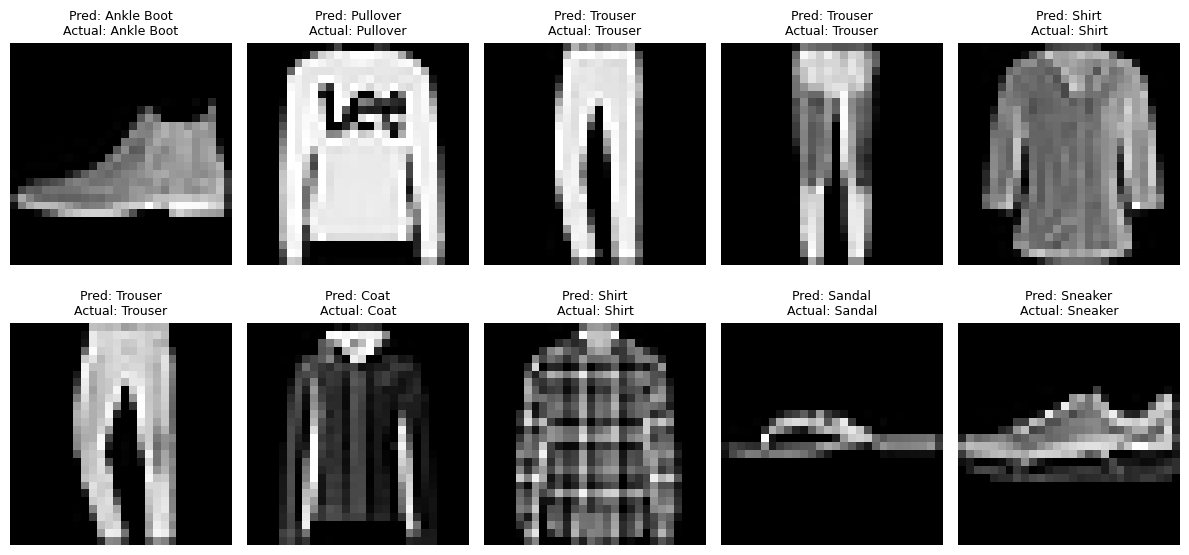

In [67]:
plt.figure(figsize=(12,6))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(X_test[i], cmap='gray')

    plt.title(
        f"Pred: {class_names[predicted_labels[i]]}\n"
        f"Actual: {class_names[y_test[i]]}",
        fontsize=9
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

In [68]:
for i in range(10):
    print(f"Image {i+1}")
    print("Predicted:", class_names[predicted_labels[i]])
    print("Actual   :", class_names[y_test[i]])
    print("-"*40)

Image 1
Predicted: Ankle Boot
Actual   : Ankle Boot
----------------------------------------
Image 2
Predicted: Pullover
Actual   : Pullover
----------------------------------------
Image 3
Predicted: Trouser
Actual   : Trouser
----------------------------------------
Image 4
Predicted: Trouser
Actual   : Trouser
----------------------------------------
Image 5
Predicted: Shirt
Actual   : Shirt
----------------------------------------
Image 6
Predicted: Trouser
Actual   : Trouser
----------------------------------------
Image 7
Predicted: Coat
Actual   : Coat
----------------------------------------
Image 8
Predicted: Shirt
Actual   : Shirt
----------------------------------------
Image 9
Predicted: Sandal
Actual   : Sandal
----------------------------------------
Image 10
Predicted: Sneaker
Actual   : Sneaker
----------------------------------------
